### Tutorial 6: Active Learning

In this tutorial, we will explore the principles of Active Learning, focusing specifically on various query functions used to select the most informative samples from an unlabeled dataset. We will begin by training a model on a small initial training set of 100 samples, then incrementally add more samples using different query strategies. Each time we expand the training set, the model will be retrained from scratch. Unlike traditional approaches, we will demonstrate that Active Learning can achieve comparable performance using significantly less labeled data. 

The four query functions that we will learn about: 
- Entropy query
- Best vs 2nd Best query
- Low confidence
- Monte-carlo sampling 

In [111]:
import torch
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, random_split
import numpy as np

### Data Loading

We will use Cifar-10 in this notebook. The code to download is also provided !! 

In [112]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = transforms.Compose([transforms.ToTensor()])

# CIFAR-10 Dataset
full_train = torchvision.datasets.CIFAR10(root='/app/src/data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='/app/src/data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


### Model Definition 

1. Use a simple CNN or a predefined ResNet Architecture from torch 
2. Make sure to use dropout which will help to implement the Monte-carlo sampling

In [113]:
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, 3, padding=1), torch.nn.ReLU(),
            torch.nn.Conv2d(32, 64, 3, padding=1), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2))
        self.fc1 = torch.nn.Linear(64 * 16 * 16, 128)
        self.act = torch.nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
        self.dropout = torch.nn.Dropout(0.5)


    def forward(self, x):
        x = self.conv(x)
        x = torch.nn.Flatten()(x)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

from torchvision.models import resnet18
model = resnet18(pretrained=False, num_classes=10)
# Model Initialization
# Train Function
def train(model, dataloader, optimizer):
    model.train()
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(images), labels)
        loss.backward()
        optimizer.step()

# Evaluate Function
def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return correct / total


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
model = SimpleCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
dataloader = DataLoader(full_train, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-5)

# Training Loop
for epoch in range(30):
    train(model, dataloader, optimizer)
    accuracy = evaluate(model, test_loader)
    scheduler.step()
    print(f'Epoch {epoch + 1}, Accuracy: {accuracy:.4f}')

### Query Sampler function


Define the following query function methods under the QuerySampler class

1. Entropy Query
2. Best vs 2nd Best Query function
3. Lowest confidence query
4. Monte-Carlo Sampling



In [103]:
from tqdm import tqdm
class QuerySampler:
    def __init__(self, n_samples):
        #self.model = model
        #self.unlabeled_loader = unlabeled_loader
        self.n_samples = n_samples

    def entropy_query(self,model, unlabeled_loader):
        model.eval()
        entropies = []
        all_indices = []
        with torch.no_grad():
            for i, (images, _) in enumerate(unlabeled_loader):
                images = images.to(device)
                output = F.softmax(model(images), dim=1)
                entropy = -torch.sum(output * torch.log(output + 1e-6), dim=1)
                entropies.extend(entropy.cpu().numpy())
                all_indices.extend(range(i * unlabeled_loader.batch_size, (i+1) * unlabeled_loader.batch_size))
        top_indices = np.argsort(entropies)[-self.n_samples:]
        return [all_indices[i] for i in top_indices]
    
    def enable_dropout(self,model):
        for m in model.modules():
            if isinstance(m, nn.Dropout):
                m.train()
    def montecarlo_sampling(self, model, unlabeled_loader):
        model.eval()
        self.enable_dropout(model)

        all_probs = []
        with torch.no_grad():
            for _ in tqdm(range(5)):
                probs = []
                for inputs, _ in unlabeled_loader:
                    inputs = inputs.cuda()
                    outputs = F.softmax(model(inputs), dim=1)
                    probs.append(outputs.cpu())
                all_probs.append(torch.cat(probs))

        stacked = torch.stack(all_probs)  # [iterations, batch, classes]
        mean_probs = stacked.mean(dim=0)
        uncertainty_scores = -torch.sum(mean_probs * torch.log(mean_probs + 1e-6), dim=1) ### try monte carlo based on variance
        # 🎯 Select top uncertain
        topk_indices = np.argsort(-uncertainty_scores)[:self.n_samples]
        print(f"Topk Indices:  {len(topk_indices)} samples selected")
        #selected_idxs = [unlabeled_idxs[i] for i in topk_indices]
        return topk_indices #entropy.numpy()
    def least_confidence_query(self, model, unlabeled_loader):
        model.eval()
        confidences = []
        all_indices = []
        with torch.no_grad():
            for i, (images, _) in enumerate(unlabeled_loader):
                images = images.to(device)
                output = F.softmax(model(images), dim=1)
                confidence, _ = output.max(dim=1)
                confidences.extend(confidence.cpu().numpy())
                all_indices.extend(range(i * unlabeled_loader.batch_size, (i+1) * unlabeled_loader.batch_size))
        top_indices = np.argsort(confidences)[:self.n_samples]
        return [all_indices[i] for i in top_indices]

    def BVB_query(self, model, unlabeled_loader):
        model.eval()
        margins = []
        all_indices = []
        with torch.no_grad():
            for i, (images, _) in enumerate(unlabeled_loader):
                images = images.to(device)
                output = F.softmax(model(images), dim=1)
                top2 = torch.topk(output, 2, dim=1).values
                margin = top2[:, 0] - top2[:, 1]
                margins.extend(margin.cpu().numpy())
                all_indices.extend(range(i * unlabeled_loader.batch_size, (i+1) * unlabeled_loader.batch_size))
        top_indices = np.argsort(margins)[:self.n_samples]
        return [all_indices[i] for i in top_indices]

        


# Initial Split
INITIAL_SIZE = 100
BATCH_SIZE = 32
QUERY_SIZE = 1500
EPOCHS = 25
ITERATIONS = 20

query = QuerySampler(QUERY_SIZE)


### Train your model with Active Query 

1. Split the dataset into labeled and unlabeled set. Set the initial labeled set to 100 for example. 
2. Train the model to convergence with the intial labeled set
3. Now use the unlabeled dataset to choose N samples using active query functions
4. Combine the initial labeled set with the choosen sample 
5. Train the model from scratch 
6. Repeat until you reach the baseline performance

In [ ]:
labeled_indices = np.random.choice(len(full_train), INITIAL_SIZE, replace=False).tolist()
unlabeled_indices = list(set(range(len(full_train))) - set(labeled_indices))
total_acc = []
for iteration in range(ITERATIONS):
    print(f"\n--- Iteration {iteration + 1} ---")
    labeled_loader = DataLoader(Subset(full_train, labeled_indices), batch_size=BATCH_SIZE, shuffle=True)
    unlabeled_loader = DataLoader(Subset(full_train, unlabeled_indices), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

    model = SimpleCNN().to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    #model = resnet18(pretrained=False, num_classes=10).to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
    EPOCHS = 30
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in tqdm(range(EPOCHS)):
        train(model, labeled_loader, optimizer)
        scheduler.step()
    acc = evaluate(model, test_loader)
    total_acc.append(acc)
    print(f"Test Accuracy: {acc:.4f} with {len(labeled_indices)} labeled samples")

    # Query new samples
    query_indices = query.margin_sampling(model, unlabeled_loader)
    newly_labeled = [unlabeled_indices[i] for i in query_indices]

    labeled_indices.extend(newly_labeled)
    unlabeled_indices = list(set(unlabeled_indices) - set(newly_labeled))

### Visualize performance of the model across all the query functions  

/tmp/ipykernel_8142/1601215045.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  file = torch.load('/app/src/cifar10_lcnfidence.pth')


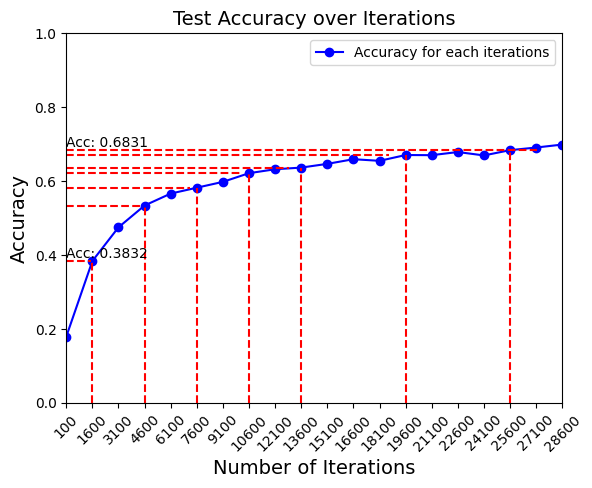

In [ ]:
import torch
import matplotlib.pyplot as plt
file = torch.load('/app/src/cifar10_lcnfidence.pth') ### Load your saved model here 
x_ = [100,1600, 3100, 4600, 6100, 7600, 9100, 10600, 12100, 13600, 15100, 16600, 18100, 19600, 21100, 22600, 24100, 25600, 27100, 28600]
plt.plot(file, marker='o', color='b', label='Accuracy for each iterations')
plt.axvline(x=1, ymin=0, ymax= file[1], color='r', linestyle='--')
plt.axvline(x=3, ymin=0, ymax= file[3], color='r', linestyle='--')
plt.axvline(x=5, ymin=0, ymax=file[5], color='r', linestyle='--')
plt.axvline(x=7, ymin=0, ymax=file[7], color='r', linestyle='--')
plt.axvline(x=9, ymin=0, ymax=file[9], color='r', linestyle='--')
#plt.axvline(x=11, ymin=0, ymax=file[11], color='r', linestyle='--')
plt.axvline(x=13, ymin=0, ymax=file[13], color='r', linestyle='--')
#plt.axvline(x=15, ymin=0, ymax=file[15], color='r', linestyle='--')
plt.axvline(x=17, ymin=0, ymax=file[17], color='r', linestyle='--')

plt.ylim(0, 1)
plt.xlim(0, len(file) - 1)
plt.axhline(y=file[1], xmax= 1/len(file), color='r', linestyle='--')
plt.axhline(y=file[3], xmax= 3/len(file), color='r', linestyle='--')
plt.axhline(y=file[5], xmax= 5/len(file), color='r', linestyle='--')
plt.axhline(y=file[7], xmax= 7/len(file), color='r', linestyle='--')
plt.axhline(y=file[9], xmax= 9/len(file), color='r', linestyle='--')
#plt.axhline(y=file[11], xmax= 11/len(file), color='r', linestyle='--')
plt.axhline(y=file[13], xmax= 13/len(file), color='r', linestyle='--')
#plt.axhline(y=file[15], xmax= 15/len(file), color='r', linestyle='--')
plt.axhline(y=file[17], xmax= 19/len(file), color='r', linestyle='--')
plt.xticks(ticks=range(len(file)), labels=x_, rotation=45)
plt.text(0, file[17]+0.01, f'Acc: {file[17]:.4f}', color='black', fontsize=10)
plt.text(0, file[1]+0.01, f'Acc: {file[1]:.4f}', color='black', fontsize=10)
plt.xlabel('Number of Iterations', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Test Accuracy over Iterations', fontsize=14)
plt.legend()
plt.show()

### Active Learning with Corrupted Cifar-10

Now that we have seen how different query functions help in selecting more informative samples, we will make the training conditions more challenging by introducing corrupted samples alongside the clean ones. Specifically, we will use the Corrupted CIFAR-10 dataset mixed with the standard CIFAR-10 dataset. The goal is to evaluate whether the query functions can effectively prioritize clean CIFAR-10 samples while ignoring the corrupted ones. Begin by downloading the Corrupted CIFAR-10 dataset, which includes various types of corruptions. Choose one or more corruption types to combine with the clean CIFAR-10 data for this experiment.

Then, we will similarily train the models using the four query functions. 

First, Download the corrupted Cifar-10: https://zenodo.org/records/2535967

In [60]:
import tarfile

tar_path = "/app/src/CIFAR-10-C.tar"
extract_path = "/app/src/"

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path)

In [104]:
import numpy as np
file = np.load('/app/src/CIFAR-10-C/brightness.npy')
file.shape

(50000, 32, 32, 3)

### Combine the corrupted samples with the clean instances

In [105]:
full_train.data = np.concatenate([full_train.data, file])
full_train.data.shape
full_train.targets = full_train.targets + full_train.targets
len(full_train.targets)
labeled_indices = np.random.choice(50000, INITIAL_SIZE, replace=False).tolist()
unlabeled_indices = list(set(range(len(full_train))) - set(labeled_indices))

### Test the different query functions with corrupted Cifar-10

In [106]:
from tqdm import tqdm
class QuerySampler:
    def __init__(self, n_samples):
        #self.model = model
        #self.unlabeled_loader = unlabeled_loader
        self.n_samples = n_samples

    def entropy_sampling(self,model, unlabeled_loader):
        model.eval()
        entropies = []
        all_indices = []
        with torch.no_grad():
            for i, (images, _) in enumerate(unlabeled_loader):
                images = images.to(device)
                output = F.softmax(model(images), dim=1)
                entropy = -torch.sum(output * torch.log(output + 1e-6), dim=1)
                entropies.extend(entropy.cpu().numpy())
                all_indices.extend(range(i * unlabeled_loader.batch_size, (i+1) * unlabeled_loader.batch_size))
        top_indices = np.argsort(entropies)[-self.n_samples:]
        return [all_indices[i] for i in top_indices]
    
    
        


# Initial Split
INITIAL_SIZE = 100
BATCH_SIZE = 32
QUERY_SIZE = 1500
EPOCHS = 25
ITERATIONS = 20

query = QuerySampler(QUERY_SIZE)
#labeled_indices = np.random.choice(len(full_train), INITIAL_SIZE, replace=False).tolist()
#unlabeled_indices = list(set(range(len(full_train))) - set(labeled_indices))
total_acc = []
for iteration in range(ITERATIONS):
    print(f"\n--- Iteration {iteration + 1} ---")
    labeled_loader = DataLoader(Subset(full_train, labeled_indices), batch_size=BATCH_SIZE, shuffle=True)
    unlabeled_loader = DataLoader(Subset(full_train, unlabeled_indices), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

    model = SimpleCNN().to(device)
    #optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    #model = resnet18(pretrained=False, num_classes=10).to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
    EPOCHS = 30
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in tqdm(range(EPOCHS)):
        train(model, labeled_loader, optimizer)
        scheduler.step()
    acc = evaluate(model, test_loader)
    total_acc.append(acc)
    print(f"Test Accuracy: {acc:.4f} with {len(labeled_indices)} labeled samples")

    # Query new samples
    query_indices = query.entropy_sampling(model, unlabeled_loader)
    newly_labeled = [unlabeled_indices[i] for i in query_indices]

    labeled_indices.extend(newly_labeled)
    unlabeled_indices = list(set(unlabeled_indices) - set(newly_labeled))

### Investigate the performance of the query functions

You have probably found out that the model doesn't achieve the similar performance by adding some corrupted samples. 
Now, let us investigate what type of samples are selected by the different query functions. 

1. Compare the number of clean samples selected by the query functions 
2. Compare the number of corrupted samples selected by the query functions 
3. Try to experiment with the hyperparameters such as the initial number of labeled samples and see whether it makes the difference or not. 

Visualize the findings !!


In [ ]:
## This should be trivial to do, just the compare the outputs of the sampler and plot the agreements. 